# Report LLM_Benchmark

## Introduction
The main goal of this project is to provide a general benchmark to evaluate different LLMs performances under different types of planning domains to better understand in advance what fre the planning capabilities of a given LLM.
In the repository the material developed by other students could be found as well as the folder containing 20 planning domains among the most important ones used at world level PDDL conferences.

## About the PDDL Domains
In order to obtain a better classification 

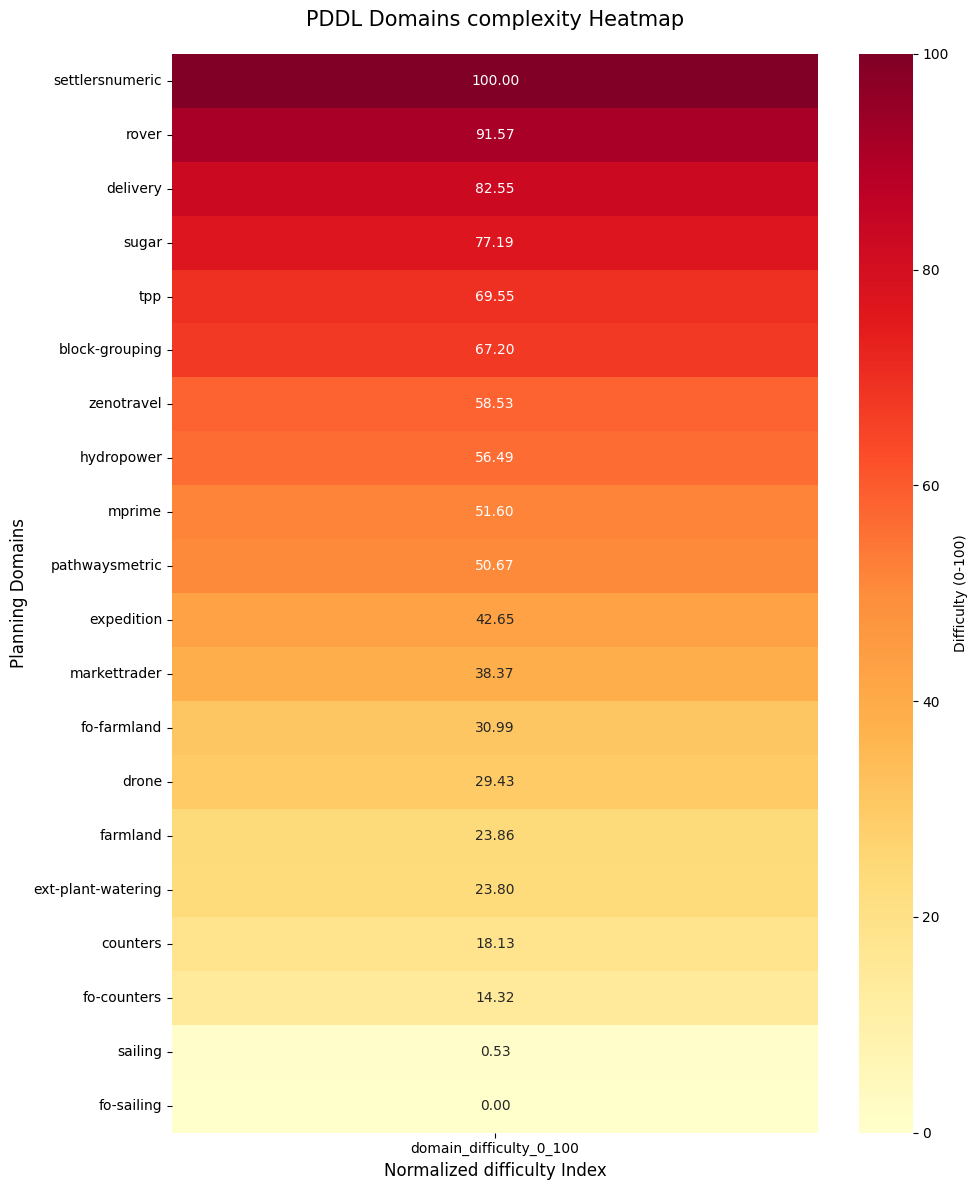

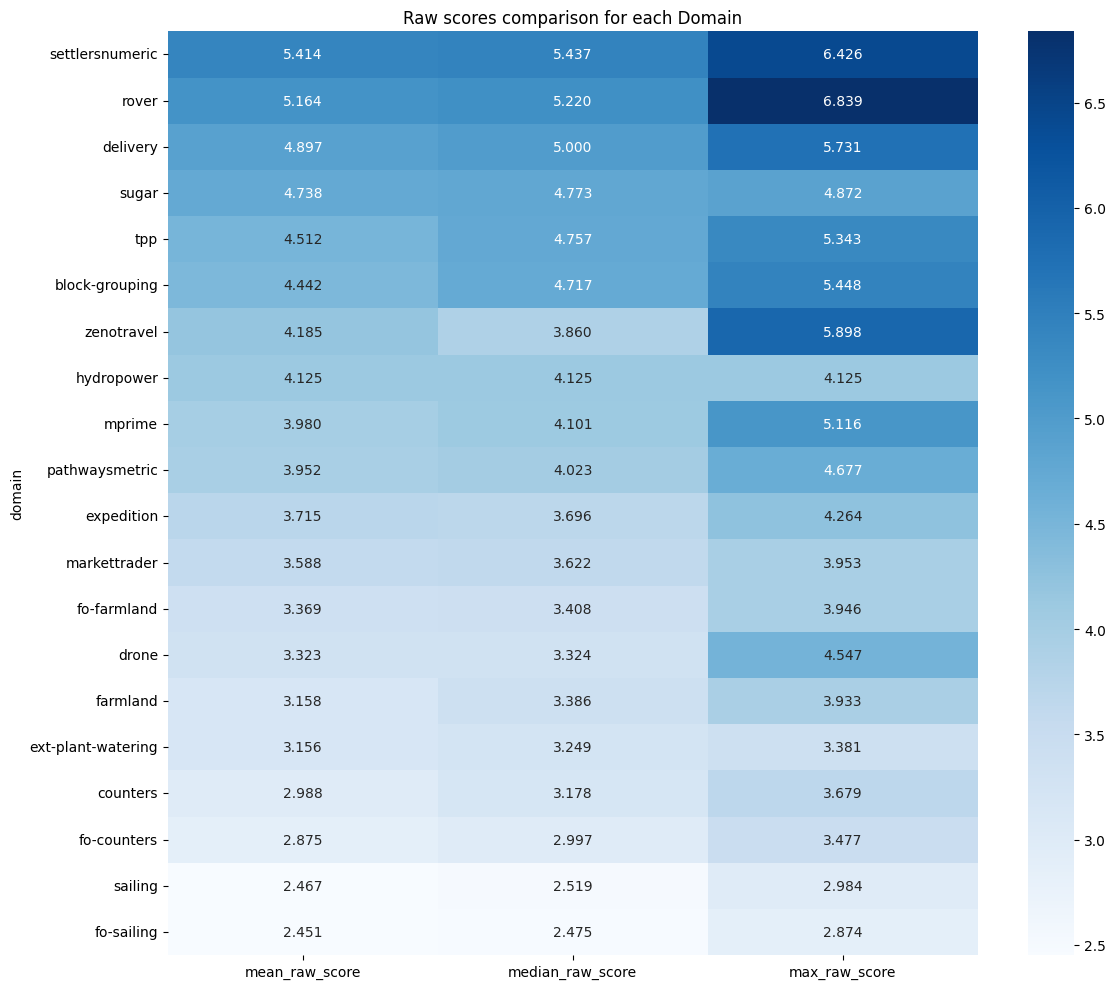

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Configurazione dei percorsi
# Partendo da analysis/notebooks, risaliamo di due livelli alla root della repo
repo_root = Path.cwd().parent.parent
summary_file = repo_root / "analysis" / "domain_complexity" / "domain_summary.csv"

# 2. Caricamento dei dati
if not summary_file.exists():
    print(f"Errore: Il file {summary_file} non esiste. Esegui prima lo script score_domains_complexity.py")
else:
    df = pd.read_csv(summary_file)

    # 3. Preparazione dei dati per la heatmap
    # Selezioniamo il dominio come indice e la colonna della difficoltà 0-100
    # Ordiniamo per difficoltà decrescente per una visualizzazione migliore
    heatmap_data = df.set_index('domain')[['domain_difficulty_0_100']].sort_values(by='domain_difficulty_0_100', ascending=False)

    # 4. Creazione della Heatmap
    plt.figure(figsize=(10, 12))
    
    # annot=True inserisce il valore numerico nelle celle
    # cmap="YlOrRd" usa una scala dal giallo (facile) al rosso (difficile)
    sns.heatmap(heatmap_data, annot=True, cmap="YlOrRd", fmt=".2f", cbar_kws={'label': 'Difficulty (0-100)'})

    plt.title('PDDL Domains complexity Heatmap', fontsize=15, pad=20)
    plt.ylabel('Planning Domains', fontsize=12)
    plt.xlabel('Normalized difficulty Index', fontsize=12)
    
    # Ottimizzazione del layout
    plt.tight_layout()
    plt.show()

    # Opzionale: Heatmap comparativa con più metriche grezze
    # Se vuoi vedere anche come si relazionano media e mediana raw:
    plt.figure(figsize=(12, 10))
    metrics_cols = ['mean_raw_score', 'median_raw_score', 'max_raw_score']
    comparative_data = df.set_index('domain')[metrics_cols].sort_values(by='mean_raw_score', ascending=False)
    
    sns.heatmap(comparative_data, annot=True, cmap="Blues", fmt=".3f")
    plt.title('Raw scores comparison for each Domain')
    plt.tight_layout()
    plt.show()


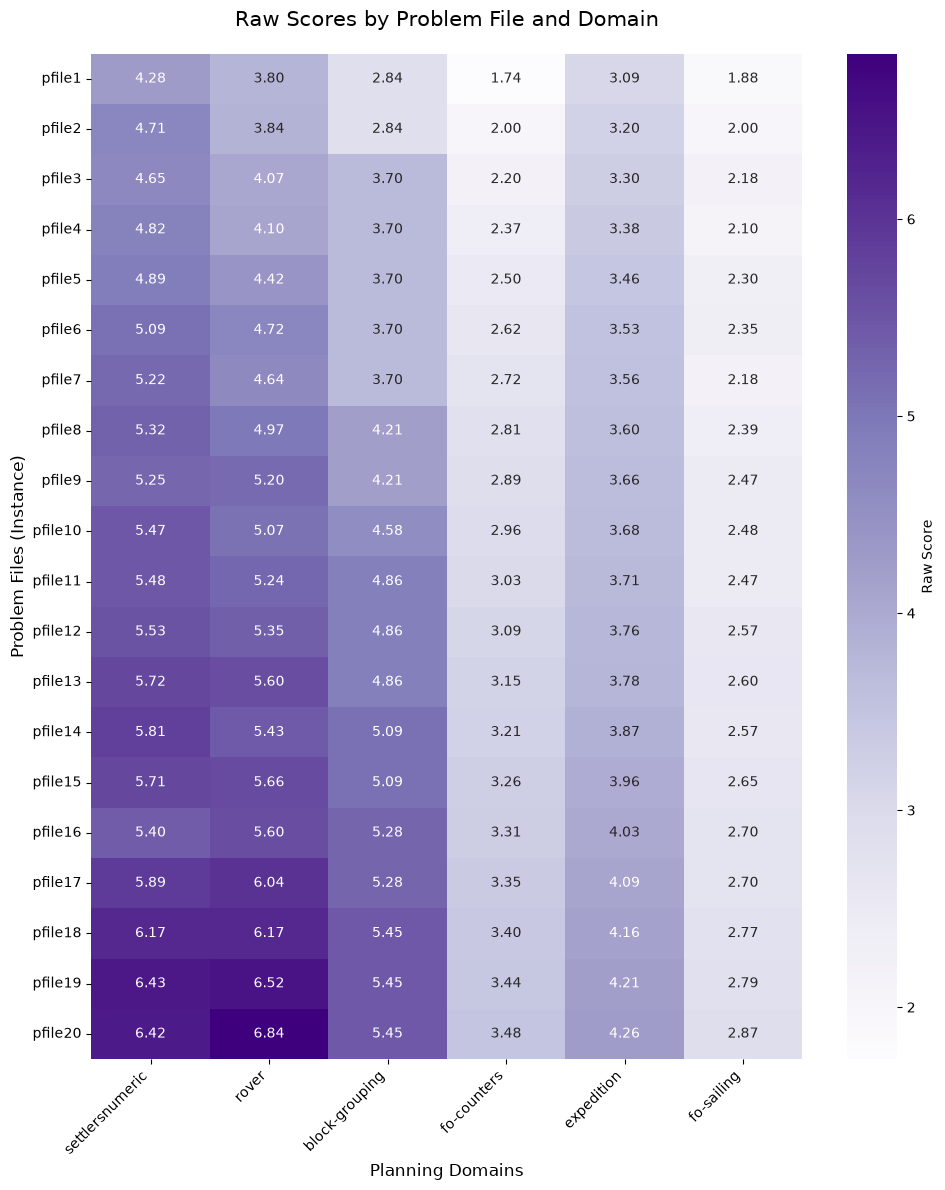

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Configurazione dei percorsi
# Partendo da analysis/notebooks, risaliamo alla root della repo
repo_root = Path.cwd().parent.parent
scores_file = repo_root / "analysis" / "domain_complexity" / "complexity_scores.csv"

# 2. Caricamento dei dati
if not scores_file.exists():
    print(f"Errore: Il file {scores_file} non esiste. Controlla il percorso.")
else:
    df = pd.read_csv(scores_file)
# 3. Preparazione dei dati per la heatmap
    target_domains = [
        'settlersnumeric', 'rover', 'block-grouping', 
        'fo-counters', 'expedition', 'fo-sailing'
    ]
    
    df_filtered = df[df['domain'].isin(target_domains)]
    
    # Creazione della matrice
    heatmap_data = df_filtered.pivot_table(
        index='instance', 
        columns='domain', 
        values='raw_score'
    )
    
    # Riordino delle colonne (i 6 domini)
    heatmap_data = heatmap_data[target_domains]
    
    # --- NUOVA AGGIUNTA: RIORDINO DELLE RIGHE ---
    # Creiamo una lista con l'ordine esatto da pfile1 a pfile20
    correct_row_order = [f"pfile{i}" for i in range(1, 21)]
    
    # Applichiamo l'ordine al dataframe. 
    # Verranno mantenute solo le righe presenti nella lista e in quell'ordine.
    heatmap_data = heatmap_data.reindex(correct_row_order)
    # --------------------------------------------

    # 4. Creazione della Heatmap
    plt.figure(figsize=(10, 12))
    
    sns.heatmap(heatmap_data, annot=True, cmap="Purples", fmt=".2f", 
                cbar_kws={'label': 'Raw Score'})

    plt.title('Raw Scores by Problem File and Domain', fontsize=15, pad=20)
    plt.ylabel('Problem Files (Instance)', fontsize=12)
    plt.xlabel('Planning Domains', fontsize=12)
    
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()